# Model Development

In this notebook, we will try to build a model that can estimate the age group of a person based on their voice.

## Data Generator

Since we have over 1 million audio samples, we will need to read the data in batches if we want to train our neural network model.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.utils import Sequence

class MelspectrogramGenerator(Sequence):
    
    def __init__(self, filenames, labels, batch_size=31):
        self.filepaths = [
            './datasets/common_voice/melspectrograms/%s' % (filename[:-4] + '.npy')
            for filename in filenames
        ]
        self.labels = labels
        self.batch_size = batch_size
        self.one_hot_encoder = {
            "under-20": 0, 
            "20-29": 1, 
            "30-39": 2, 
            "40-49": 3, 
            "50-59": 4, 
            "60+": 5
        }
    
    def __len__(self):
        return (np.ceil(len(self.filepaths) / float(self.batch_size))).astype(np.int)
    
    def __getitem__(self, index):
        start = index * self.batch_size
        stop = (index + 1) * self.batch_size
        
        batch_filepaths = self.filepaths[start: stop]
        batch_labels = self.labels[start: stop]
        
        x_batch = []
        for filepath in batch_filepaths:
            x_batch.append(np.load(filepath))
            
        x_batch = np.array(x_batch)
        y_batch = np.zeros((len(batch_labels), 6))
        
        for i, batch_label in enumerate(batch_labels):
            j = self.one_hot_encoder[batch_label]
            y_batch[i, j] = 1
        
        return x_batch, y_batch

Let's use our training set, and our validation set. From here we will use the results on the validation set to see which improvements we can make in our model.

In [2]:
def data_generator(filepath):
    dataframe = pd.read_csv(filepath)
    
    filenames = list(dataframe.filename)
    labels = list(dataframe.age)
    generator = MelspectrogramGenerator(filenames, labels)
    
    return generator

training_generator = data_generator("./datasets/common_voice/training.csv")
validation_generator = data_generator("./datasets/common_voice/validation.csv")

## Model Architecture

In [3]:
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import BatchNormalization, Concatenate, Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

pretrained_params = {
    'input_shape': (128, 431, 3), 
    'include_top': False,
    'weights': 'imagenet'
}

Pretrained_DenseNet = DenseNet169(**pretrained_params)

input_layer = Input(shape=(128, 431, 1))

x = Concatenate()([input_layer, input_layer, input_layer])
x = Pretrained_DenseNet(x)
x = Flatten()(x)

x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.10)(x)

x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.10)(x)

x = BatchNormalization()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.10)(x)

x = BatchNormalization()(x)
x = Dense(32, activation='relu')(x)

output_layer = Dense(6, activation='softmax')(x)

model = Model(
    inputs=input_layer, 
    outputs=output_layer
)
model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)
model.summary()

2023-01-07 11:45:01.961012: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-07 11:45:01.966248: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-07 11:45:01.966839: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-07 11:45:01.967779: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 128, 431, 1) 0                                            
__________________________________________________________________________________________________
concatenate (Concatenate)       (None, 128, 431, 3)  0           input_2[0][0]                    
                                                                 input_2[0][0]                    
                                                                 input_2[0][0]                    
__________________________________________________________________________________________________
densenet169 (Functional)        (None, 4, 13, 1664)  12642880    concatenate[0][0]                
______________________________________________________________________________________________

## Model Training

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint

cp_callback = ModelCheckpoint(
    filepath='models/hdf5/model12/model12-{epoch:02d}.hdf5'
)

train_log = model.fit(
    training_generator, 
    epochs=4, 
    verbose=1, 
    validation_data=validation_generator,
    callbacks=[cp_callback]
)

Epoch 1/4


2023-01-07 11:45:04.471266: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2023-01-07 11:45:12.166190: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8201
2023-01-07 11:45:12.716345: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-07 11:45:12.716737: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-07 11:45:12.716754: W tensorflow/stream_executor/gpu/asm_compiler.cc:77] Couldn't get ptxas version string: Internal: Couldn't invoke ptxas --version
2023-01-07 11:45:12.717192: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-07 11:45:12.717234: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] Internal: Failed to launch ptxas
Relying on driver to perform ptx co

34407/34407 [==============================] - 10481s 304ms/step - loss: 0.8501 - accuracy: 0.6826 - val_loss: 0.5390 - val_accuracy: 0.8061
Epoch 2/4
34407/34407 [==============================] - 10442s 303ms/step - loss: 0.4529 - accuracy: 0.8408 - val_loss: 0.3609 - val_accuracy: 0.8732
Epoch 3/4
34407/34407 [==============================] - 10455s 304ms/step - loss: 0.3070 - accuracy: 0.8937 - val_loss: 0.3091 - val_accuracy: 0.8929
Epoch 4/4
34407/34407 [==============================] - 10545s 306ms/step - loss: 0.2255 - accuracy: 0.9227 - val_loss: 0.2496 - val_accuracy: 0.9150


### Loss Curves, and Accuracy Curves

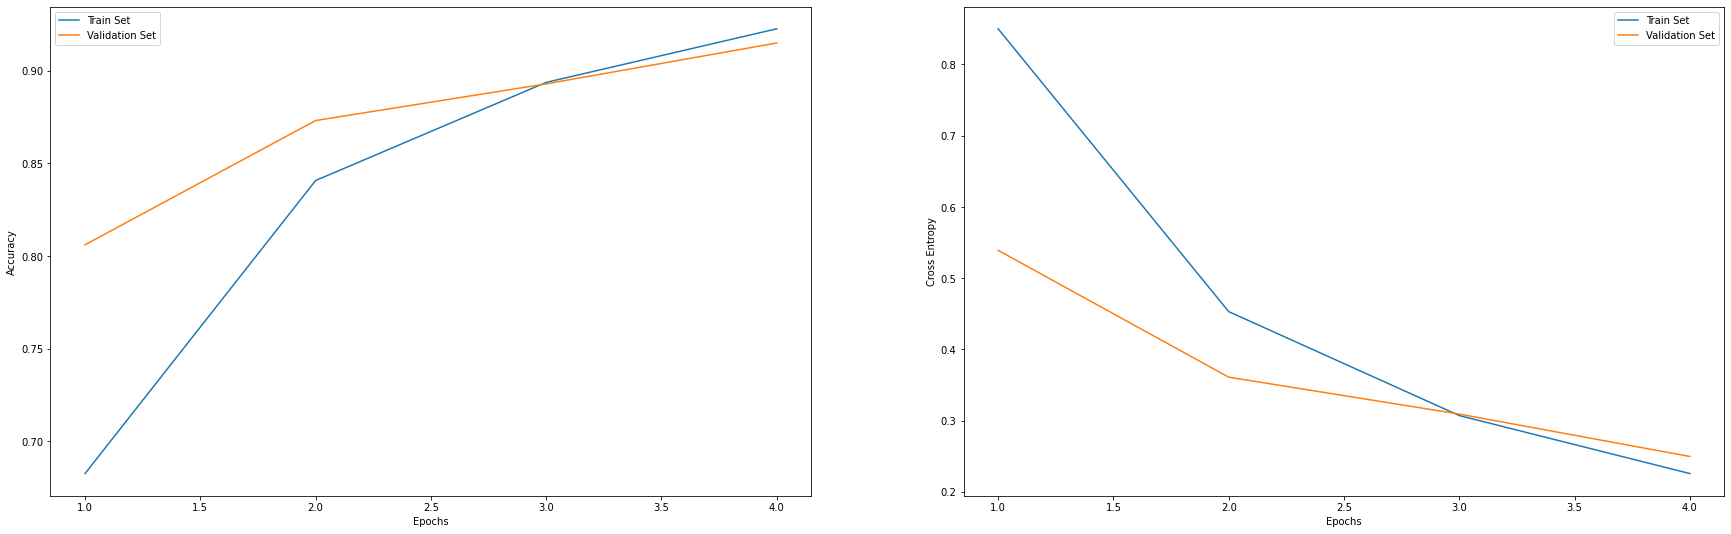

In [5]:
import matplotlib.pyplot as plt

def plot_curves(train_log):
    fig = plt.figure(figsize=(30, 9))
    
    epochs = len(train_log.history['accuracy'])
    x_labels = [i + 1 for i in range(epochs)]

    train_accuracies = train_log.history['accuracy']
    val_accuracies = train_log.history['val_accuracy']
    train_losses = train_log.history['loss']
    val_losses = train_log.history['val_loss']

    plt.subplot(1, 2, 1)
    plt.plot(x_labels, train_accuracies, label='Train Set')
    plt.plot(x_labels, val_accuracies, label='Validation Set')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(x_labels, train_losses, label='Train Set')
    plt.plot(x_labels, val_losses, label='Validation Set')
    plt.xlabel("Epochs")
    plt.ylabel("Cross Entropy")
    plt.legend()

    plt.show()
    
plot_curves(train_log)

## Model Evaluation

In [7]:
from tensorflow.keras.models import load_model

model = load_model('models/hdf5/model12/model12-04.hdf5')

predictions = model.predict(validation_generator)
predictions = predictions.argmax(axis=1)

validation_df = pd.read_csv("./datasets/common_voice/validation.csv")
labels = ["under-20", "20-29", "30-39", "40-49", "50-59", "60+"]

actuals = validation_df.age.apply(lambda age: labels.index(age))
actuals = np.array(actuals)

Now that we have consolidated our actual labels, and predicted labels, let's plot out our confusion matrices and see the results.

In [8]:
import pandas as pd
import seaborn as sns

from sklearn.metrics import confusion_matrix

def recall_confusion_plot(actuals, predictions):
    confusion = confusion_matrix(actuals, predictions)
    confusion = confusion.astype("float") / confusion.sum(axis=1).reshape(-1,1)
    
    df_cm = pd.DataFrame(confusion, index=labels, columns=labels)
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'
    
    plt.figure(figsize=(20, 14))
    plt.title("Recall and Miss Rate")
    sns.set(font_scale=1.4)
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16})
    plt.show()
    
def precision_confusion_plot(actuals, predictions):
    confusion = confusion_matrix(actuals, predictions)
    confusion = confusion.astype("float") / confusion.sum(axis=0)
    
    df_cm = pd.DataFrame(confusion, index=labels, columns=labels)
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'
    
    plt.figure(figsize=(20, 14))
    plt.title("Precision and False Discovery")
    sns.set(font_scale=1.4)
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16})
    plt.show()

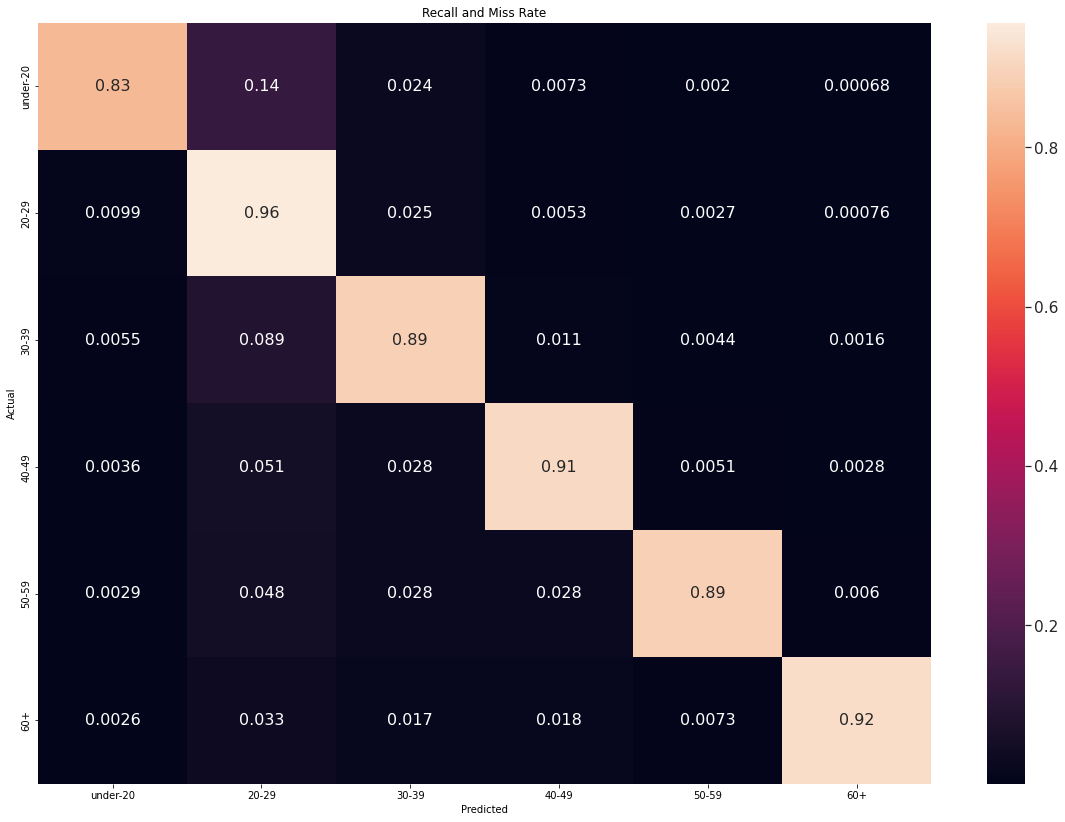

In [9]:
#Rows add up to 1
recall_confusion_plot(actuals, predictions)

The above plot is the ***Recall and Miss Rate Confusion Matrix***. 
 * All the rows of the above matrix add up to one. 
 * The diagonal values correspond to recall scores, while the off diagonal scores correspond to the miss rate scores. 
 * The value at the *i*th row, and *j*th column is the probability that the model predicts the audio sample belongs to the *j*th column given that the audio sample actually belongs to the *i*th row.

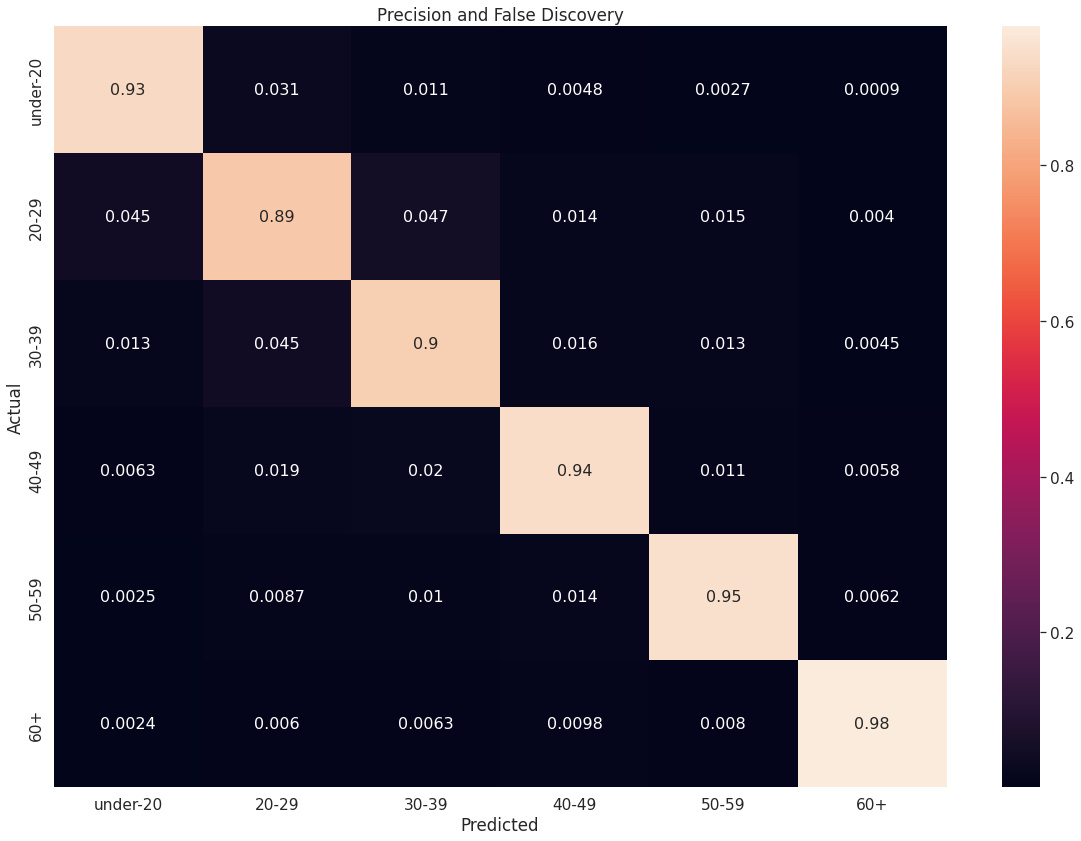

In [10]:
#Columns add up to 1
precision_confusion_plot(actuals, predictions)

The above plot is the ***Precision and False Discovery Confusion Matrix***. 
 * All the columns of the above matrix add up to one. 
 * The diagonal values correspond to precision scores, while the off diagonal scores correspond to the false discovery scores. 
 * The value at the *i*th row, and *j*th column is the probability that the audio sample actually belongs to the *i*th row given that the model predicts the audio sample belongs to the *j*th column.